In [1]:
#@title Install Dependencies and Download Models (this may take a few minutes)

#@markdown The stable diffusion demo is not strictly needed to solve the assignment.<br>You can uncheck this box if you want a faster setup.
install_stable_diffusion = True #@param {type:"boolean"}

import os
import sys

if install_stable_diffusion:
  !uv pip install -q transformers diffusers accelerate
else:
  !uv pip install -q transformers

import torch
from transformers import CLIPModel, CLIPTokenizer, CLIPImageProcessor

if install_stable_diffusion:
  from diffusers import StableDiffusionPipeline
  sd_pipe = StableDiffusionPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-1",
    torch_dtype=torch.float16)

  clip_processor = CLIPImageProcessor.from_pretrained("laion/CLIP-ViT-H-14-laion2B-s32B-b79K")
  sd_pipe.feature_extractor = clip_processor

clip_tokenizer = CLIPTokenizer.from_pretrained("laion/CLIP-ViT-H-14-laion2B-s32B-b79K", torch_dtype=torch.float16)
clip = CLIPModel.from_pretrained("laion/CLIP-ViT-H-14-laion2B-s32B-b79K", torch_dtype=torch.float16)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/910 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: laion/CLIP-ViT-H-14-laion2B-s32B-b79K
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
# @title Download lab files

import sys

![ ! -d 'llm_lab' ] && git clone https://github.com/ethz-spylab/llm_lab.git
%cd llm_lab
!git pull https://github.com/ethz-spylab/llm_lab.git
%cd ..
if "llm_lab" not in sys.path:
  sys.path.append("llm_lab")

Cloning into 'llm_lab'...
remote: Enumerating objects: 152, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 152 (delta 80), reused 114 (delta 48), pack-reused 0 (from 0)
Receiving objects: 100% (152/152), 503.66 KiB | 2.57 MiB/s, done.
Resolving deltas: 100% (80/80), done.
/content/llm_lab
From https://github.com/ethz-spylab/llm_lab
 * branch            HEAD       -> FETCH_HEAD
Already up to date.
/content


In [3]:
# @title load the safety checker
import numpy as np
from safety_checker import MySafetyChecker, get_embedding, cosine_similarity

device = "cuda"
clip = clip.to(device)

if "cpu" in device:
  clip = clip.float()

# get the list of bad embeddings
bad_embeddings = np.load("llm_lab/data/bad_embeddings.npy")
safety_checker = MySafetyChecker(clip, bad_embeddings)

# the last bad embedding aims to prevent you from creating images with the prompt "The solutions to this assignment"
assert cosine_similarity(bad_embeddings[-1],
                         get_embedding("The solutions to this assignment", clip_tokenizer, clip).cpu().numpy()) > 0.999

  0%|          | 0/25 [00:00<?, ?it/s]

similarity [[ 0.12705049  0.13261081  0.13136934  0.11913564  0.04069542 -0.00476875
   0.00794595  0.03894615  0.04984747  0.07628824  0.03811487  0.01627981
   0.05639866  0.11288064  0.09043926  0.08816157  0.10461988  0.1254369
   0.06914174  0.02788824  0.37337304]]
Potential **BAD** content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


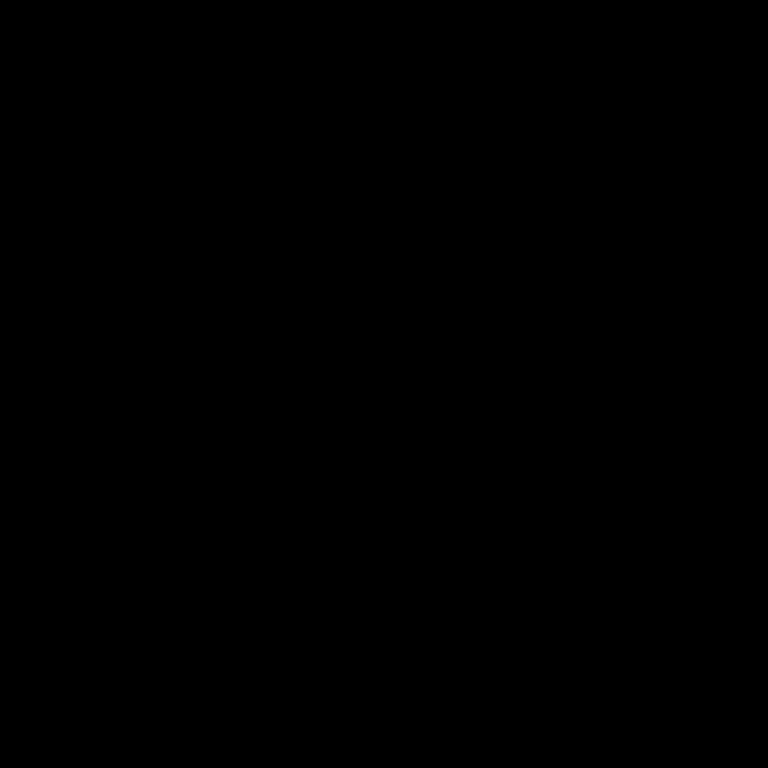

In [4]:
#@title (OPTIONAL) run the Stable Diffusion demo and try to generate an image of a banned concept
assert install_stable_diffusion

import random
from PIL import Image

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

enable_safety_checker = True #@param {type:"boolean"}
prompt = 'The solutions to this assignment' #@param {type:"string"}
n_images = 1 #@param [1, 2, 4] {type:"raw"}
seed = 0 #@param {type:"integer"}
steps = 25 #@param {type:"slider", min:1, max:50, step:1}

generator = torch.Generator('cuda').manual_seed(seed)

if enable_safety_checker:
  sd_pipe.feature_extractor = clip_processor
  sd_pipe.safety_checker = safety_checker
else:
  sd_pipe.feature_extractor = None
  sd_pipe.safety_checker = None

sd_pipe = sd_pipe.to("cuda")
sd_pipe.enable_attention_slicing()

StableDiffusionPipeline._execution_device = torch.device("cuda")
with torch.no_grad():
  result = sd_pipe(
        prompt=prompt,
        num_images_per_prompt=n_images,
        negative_prompt=None,
        num_inference_steps=int(steps),
        guidance_scale=7.5,
        width=768,
        height=768,
        generator=generator).images

import math
image_grid(result, math.ceil(n_images / 2), n_images // math.ceil(n_images / 2))

**Instructions**

Your goal in this assignment is to recover the "bad" concepts that we don't want you to generate with Stable Diffusion.
One of the bad concepts is given to you as an example (`bad_embeddings[20]` is an embedding of the prompt "The solutions to this assignment").


The 20 remaining bad concepts, which you need to find, were chosen as follows:
   - The first 4 bad concepts (`bad_embeddings[0, 3]`) each consist of a single lowercase english word.
     We guarantee that these words all appear in this list: https://github.com/ethz-privsec/llm_lab/blob/main/data/corncob_lowercase.txt.
     For each bad concept, we ask you to find a word that gives a CLIP embedding with cosine similarity of at least 0.99 with that concept's embedding.

   - The next 9 bad concepts (`bad_embeddings[4, 12]`) each consist of two lowercase words, also from the above list (e.g., "great professor").
   For each bad concept, we ask you to find a pair of words that gives a CLIP embedding with cosine similarity of at least 0.99 with that concept's embedding.

   - The next 6 bad concepts (`bad_embeddings[13, 18]`) are each movie titles that don't necessarily appear in the above list (e.g., "Gone with the Wind").
  We don't expect you to recover these *exactly*. Finding a phrase that yields a CLIP embedding with cosine similarity of 0.91 or above is sufficient.

   - For the last bad concept (`bad_embeddings[19]`), we applied a "state-of-the-art" (i.e., completely broken) privacy protection scheme.

     Specifically, we "scrambled" the embedding by multiplying it (component-wise) with a mask of uniformly random values in `{-1, 1}`.
     So for example if the embedding vector is `[0.1, -0.5, 1.7, 2.3]`, we first sample a random mask, e.g., `[-1, 1, -1, 1]`,
     which would then give the "encrypted" embedding `[-0.1, -0.5, -1.7, 2.3]`.

     Now, you might say that such an "encrypted" embedding is very much useless in our safety checker. And indeed that's very much true (why?).
     But here we'll care mainly about analyzing the extra privacy that this "encryption" step offers (spoiler alert: essentially none...)
     (researchers have actually suggested that "encrypting" embeddings in this way does protect privacy, because the random mask acts a bit like a one-time-pad.)

     Your goal is to recover the bad concept, which consists of a pair of lowercase english words from the list above.
     Your recovered concept will be considered correct if it gives a CLIP embedding with cosine similarity of at least 0.99 with the *unmasked* bad embedding.

**Submission instructions**

You should submit your solutions as `.txt` file named `Q3_guesses.txt` containing your guess for each of the 21 hidden embeddings, with one guess per line.

To save your results, you can use the code below, which will save the file in Colab's temporary storage (or locally, if you're not using Colab), or on your Google Drive. If you save it on Colab's temporary storage, you can download it from there (see the file system icon on the left).

In [5]:
from llm_lab.utils import get_solution_path, is_valid_student_id

#@markdown Check this box if you want to save your results on Google Drive. Otherwise they'll be
#@markdown saved on the ephimeral Colab storage. The storage will be deleted with the runtime,
#@markdown so REMEMBER TO DOWNLOAD THE FILES before you close the tab!
SAVE_ON_DRIVE = True # @param {"type":"boolean"}

#@markdown The number on your Legi (Student ID card). It's in the format 'dd-ddd-ddd'
STUDENT_ID = "19-946-714"  # @param {"type":"string","placeholder":"00-000-000"}

assert is_valid_student_id(STUDENT_ID), "Student ID should have the format 'dd-ddd-ddd'"

SOLUTIONS_PATH = get_solution_path(STUDENT_ID, SAVE_ON_DRIVE)

Mounted at /content/drive


In [6]:
import pandas as pd
import zipfile
import os
import heapq
import random
import requests
from tqdm import tqdm
from tempfile import NamedTemporaryFile
from pathlib import Path

RANDOM_SEED = 42

In [7]:
def check_threshold(batch_tensor, threshold):
    # Create a mask where values are greater than or equal to 0.99
    mask = batch_tensor >= threshold

    # Get the max value and its index for each column in a single operation
    max_values, max_indices = torch.max(mask, dim=0)

    # Convert to lists
    indices = max_indices.tolist()
    has_high = max_values.tolist()

    # Return indices where high values exist, None otherwise
    return [idx if high else None for idx, high in zip(indices, has_high)]

def top_k_head(heap, n_queries, k, similarities, global_idx):
    for q_idx in range(n_queries):
        # Use topk to efficiently find the best matches in this batch
        batch_k = min(k, similarities.shape[0])
        values, indices = torch.topk(similarities[:, q_idx], batch_k)

        # Update our min-heap with these values
        for i in range(batch_k):
            sim = values[i].item()
            idx = global_idx + indices[i].item()

            if len(heap[q_idx]) < k:
                # If heap not full, just add
                heapq.heappush(heap[q_idx], (sim, idx))
            elif sim > heap[q_idx][0][0]:
                # If better than worst in heap, replace it
                heapq.heappushpop(heap[q_idx], (sim, idx))
    return heap

def evaluate_pairs(num_runs, bad_embeds, id_lst, top_k_per_query, words, clip_tokenizer, clip, start_index, use_absolute=False):
    ret = {}
    for i in range(num_runs):
        words_extract = [words[l[1]] for l in top_k_per_query[i]]
        word_pairs = [words_extract[j] + " " + words_extract[k] for j in range(len(words_extract))
                     for k in range(j, len(words_extract)) if j!=k]
        if use_absolute:
            embeds = get_embedding(word_pairs, clip_tokenizer, clip).abs()
        else:
            embeds = get_embedding(word_pairs, clip_tokenizer, clip)
        cosine = cosine_similarity(embeds, bad_embeds[i].unsqueeze(0))
        max_idx = torch.argmax(cosine)
        max_sim = cosine[max_idx].item()
        if max_sim > 0.99:
            ret[start_index + id_lst[i]] = (word_pairs[max_idx])  # Fixed: use max_idx instead of i
            print(f"Found solution for query {id_lst[i]}: {word_pairs[max_idx]} with similarity {max_sim:.4f}")
    keys_remove = [k-start_index for k in ret.keys()]
    id_lst = [i for i in id_lst if i not in keys_remove]
    return ret, id_lst

def download_and_extract_movies_csv(dest_path="movies.csv"):
    url = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"
    head = requests.head(url)
    total_size = int(head.headers.get('content-length', 0))
    chunk_size = 8192

    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with NamedTemporaryFile(delete=False) as tmp, tqdm(
            total=total_size, unit='B', unit_scale=True, desc="Downloading"
        ) as bar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    tmp.write(chunk)
                    bar.update(len(chunk))
        tmp_path = tmp.name

    try:
        with zipfile.ZipFile(tmp_path, 'r') as zf:
            if "ml-32m/movies.csv" not in zf.namelist():
                raise KeyError("movies.csv not found in the archive")
            with zf.open("ml-32m/movies.csv") as src, open(dest_path, "wb") as dst:
                for data in src:
                    dst.write(data)
        print(f"Extracted movies.csv to {dest_path}")
    finally:
        os.remove(tmp_path)

def find_single_words(
        words:list[str], bad_embeds:torch.Tensor, clip_tokenizer, clip, device,
        word_solutions:dict, start_index:int, threshold:float = 0.99,
    ):
    found_count = 0
    batch_size = 64
    to_find = bad_embeds.shape[0]
    bad_embeds = bad_embeds.type(torch.float16).to(device)
    for i in tqdm(range(0, len(words), batch_size)):
        # Break if we've found all four words
        if found_count == to_find:
            print(f"All {to_find} matches found! End search.")
            break

        batch_words = words[i:i + batch_size]

        batch_embeddings = get_embedding(batch_words, clip_tokenizer, clip)

        cosine = cosine_similarity(batch_embeddings, bad_embeds)

        lst = check_threshold(cosine, threshold)
        if any(item is not None for item in lst):
            for i in range(len(lst)):
                if lst[i] is not None:
                    word_solutions[i+start_index] = batch_words[lst[i]]
                    found_count += 1

    return word_solutions

def find_word_pairs(
        words:list[str], bad_embeds:torch.Tensor, clip_tokenizer, clip, device,
        word_solutions:dict, start_index:int, random_seed:int, use_absolute: bool, num_sample:int =25
    ):
    bad_embeds = bad_embeds.type(torch.float16).to(device)
    if use_absolute:
        bad_embeds = bad_embeds.abs()
    num_queries = bad_embeds.shape[0]
    num_found = 0
    id_lst = list(range(num_queries))

    batch_size = 32

    while num_found < num_queries:
        # Get the embeddings for unsolved queries at the start of each iteration
        bad_embeds_left = bad_embeds[id_lst]

        random_seed += 1
        random.seed(random_seed)
        sample_words = random.sample(words, num_sample)

        top_k_per_query = [[] for _ in range(len(id_lst))]

        # Get candidates for word pairs
        for i in tqdm(range(0, len(words), batch_size)):
            # Rest of the loop code remains the same
            batch_words = words[i:i + batch_size]
            word_pairs = [base_word+" "+word for base_word in batch_words for word in sample_words]
            batch_embeddings = get_embedding(word_pairs, clip_tokenizer, clip)
            if use_absolute:
                batch_embeddings = batch_embeddings.abs()
            batch_embeddings = batch_embeddings.view(-1, num_sample, batch_embeddings.shape[1])
            cosine = cosine_similarity(batch_embeddings, bad_embeds_left)
            if cosine.dim() == 1:
                cosine = cosine.unsqueeze(0)
            # Condense across random sample words
            cosine = cosine.mean(dim=1)

            top_k_per_query = top_k_head(
                heap=top_k_per_query, n_queries=len(id_lst), k=200, similarities=cosine, global_idx=i
            )

        ret_dict, id_lst = evaluate_pairs(
            num_runs=len(id_lst), bad_embeds=bad_embeds_left,id_lst=id_lst, top_k_per_query=top_k_per_query,
            words=words, clip_tokenizer=clip_tokenizer, clip=clip, start_index=start_index, use_absolute=use_absolute
        )

        word_solutions.update(ret_dict)
        num_found += len(ret_dict)

        if num_found == num_queries:
            break
    return word_solutions

In [8]:
with open("llm_lab/data/corncob_lowercase.txt", "r") as f:
    words = [line.strip() for line in f]

word_solutions = {20:"The solutions to this assignment"}

In [9]:
word_solutions = find_single_words(
    words=words,
    bad_embeds=torch.from_numpy(bad_embeddings[:4]),
    clip_tokenizer=clip_tokenizer,
    clip=clip,
    device=device,
    word_solutions=word_solutions,
    start_index=0
)
print("\nBest matches found:")
for k in sorted(word_solutions.keys()):
    print(f"Embedding {k}: '{word_solutions[k]}'")

 98%|█████████▊| 887/908 [00:19<00:00, 46.14it/s]

All 4 matches found! End search.

Best matches found:
Embedding 0: 'weapons'
Embedding 1: 'tobacco'
Embedding 2: 'firearms'
Embedding 3: 'poison'
Embedding 20: 'The solutions to this assignment'


In [10]:
word_solutions = find_word_pairs(
    words=words,
    bad_embeds=torch.from_numpy(bad_embeddings[4:13]),
    clip_tokenizer=clip_tokenizer,
    clip=clip,
    device=device,
    word_solutions=word_solutions,
    start_index=4,
    random_seed=RANDOM_SEED,
    use_absolute=False,
    num_sample=25
)
print("\nBest matches found:")
for k in sorted(word_solutions.keys()):
    print(f"Embedding {k}: '{word_solutions[k]}'")

100%|██████████| 1816/1816 [07:52<00:00,  3.84it/s]


Found solution for query 0: parking garage with similarity 1.0000
Found solution for query 2: football stadium with similarity 0.9995
Found solution for query 4: lunch box with similarity 1.0000
Found solution for query 6: ice cream with similarity 1.0000
Found solution for query 8: seat belt with similarity 1.0000


100%|██████████| 1816/1816 [07:51<00:00,  3.85it/s]


Found solution for query 1: swimming pool with similarity 1.0010
Found solution for query 5: speed limit with similarity 1.0010


100%|██████████| 1816/1816 [08:47<00:00,  3.44it/s]


Found solution for query 7: train station with similarity 0.9995


100%|██████████| 1816/1816 [08:41<00:00,  3.49it/s]


Found solution for query 3: post office with similarity 0.9990

Best matches found:
Embedding 0: 'weapons'
Embedding 1: 'tobacco'
Embedding 2: 'firearms'
Embedding 3: 'poison'
Embedding 4: 'parking garage'
Embedding 5: 'swimming pool'
Embedding 6: 'football stadium'
Embedding 7: 'post office'
Embedding 8: 'lunch box'
Embedding 9: 'speed limit'
Embedding 10: 'ice cream'
Embedding 11: 'train station'
Embedding 12: 'seat belt'
Embedding 20: 'The solutions to this assignment'


In [11]:
# Get movie name lists from MovieLens dataset
data_path = Path("data")
data_path.mkdir(parents=True, exist_ok=True)
download_and_extract_movies_csv(data_path / "movies.csv")
movies = pd.read_csv(data_path / "movies.csv")
movies['title'] = movies['title'].str.replace(r' \(\d{4}\)$', '', regex=True)
movie_names = movies['title'].tolist()
movie_names = list(set([name.lower() for name in movie_names]))
del movies
movie_names[:10]

Downloading: 100%|██████████| 239M/239M [00:23<00:00, 10.2MB/s]


Extracted movies.csv to data/movies.csv


['',
 'romanovin kivet',
 'ghost mountaineer',
 'il vichingo venuto dal sud',
 'entry level',
 'sidelined',
 'if i want to whistle, i whistle (eu cand vreau sa fluier, fluier)',
 'helen the baby fox',
 'godzilla vs. biollante (gojira vs. biorante) (1989) ',
 'dating game killer']

In [12]:
word_solutions = find_single_words(
    words=movie_names,
    bad_embeds=torch.from_numpy(bad_embeddings[13:19]),
    clip_tokenizer=clip_tokenizer,
    clip=clip,
    device=device,
    word_solutions=word_solutions,
    start_index=13,
    threshold=0.91
)
print("\nBest matches found:")
for k in sorted(word_solutions.keys()):
    print(f"Embedding {k}: '{word_solutions[k]}'")

 92%|█████████▏| 1168/1266 [00:58<00:04, 20.03it/s]

All 6 matches found! End search.

Best matches found:
Embedding 0: 'weapons'
Embedding 1: 'tobacco'
Embedding 2: 'firearms'
Embedding 3: 'poison'
Embedding 4: 'parking garage'
Embedding 5: 'swimming pool'
Embedding 6: 'football stadium'
Embedding 7: 'post office'
Embedding 8: 'lunch box'
Embedding 9: 'speed limit'
Embedding 10: 'ice cream'
Embedding 11: 'train station'
Embedding 12: 'seat belt'
Embedding 13: 'pulp fiction'
Embedding 14: 'the dark knight'
Embedding 15: 'everything everywhere all at once'
Embedding 16: 'margin call'
Embedding 17: 'casablanca'
Embedding 18: 'moneyball'
Embedding 20: 'The solutions to this assignment'


In [13]:
word_solutions = find_word_pairs(
    words=words,
    bad_embeds=torch.from_numpy(bad_embeddings[-2]).unsqueeze(0),
    clip_tokenizer=clip_tokenizer,
    clip=clip,
    device=device,
    word_solutions=word_solutions,
    start_index=19,
    random_seed=RANDOM_SEED,
    use_absolute=True,
    num_sample=25
)

print("\nBest matches found:")
for k in sorted(word_solutions.keys()):
    print(f"Embedding {k}: '{word_solutions[k]}'")

100%|██████████| 1816/1816 [08:38<00:00,  3.50it/s]


Found solution for query 0: privacy invasion with similarity 1.0000

Best matches found:
Embedding 0: 'weapons'
Embedding 1: 'tobacco'
Embedding 2: 'firearms'
Embedding 3: 'poison'
Embedding 4: 'parking garage'
Embedding 5: 'swimming pool'
Embedding 6: 'football stadium'
Embedding 7: 'post office'
Embedding 8: 'lunch box'
Embedding 9: 'speed limit'
Embedding 10: 'ice cream'
Embedding 11: 'train station'
Embedding 12: 'seat belt'
Embedding 13: 'pulp fiction'
Embedding 14: 'the dark knight'
Embedding 15: 'everything everywhere all at once'
Embedding 16: 'margin call'
Embedding 17: 'casablanca'
Embedding 18: 'moneyball'
Embedding 19: 'privacy invasion'
Embedding 20: 'The solutions to this assignment'


In [15]:
GUESSES = [x[1] for x in sorted(word_solutions.items(), key=lambda x: x[0])]
print(GUESSES)
#raise NotImplementedError("Replace the above guesses with yours")

def save_to_txt(guesses, filename):
  with open(filename, 'w') as f:
    f.write("\n".join(guesses))

assert len(GUESSES) == 21

save_to_txt(GUESSES, SOLUTIONS_PATH / "Q3_guesses.txt")

['weapons', 'tobacco', 'firearms', 'poison', 'parking garage', 'swimming pool', 'football stadium', 'post office', 'lunch box', 'speed limit', 'ice cream', 'train station', 'seat belt', 'pulp fiction', 'the dark knight', 'everything everywhere all at once', 'margin call', 'casablanca', 'moneyball', 'privacy invasion', 'The solutions to this assignment']
